# Component Latency Profiling: SAM1 vs SAM2 vs SAM3
Measures attention, MLP, and LayerNorm latency in the image encoder of each model family.
Results are visualized as grouped and stacked bar plots.

| Model | Source | Backbone |
|-------|--------|----------|
| SAM1  | local checkpoint | ViT-L (32 blocks) |
| SAM2  | `facebook/sam2-hiera-large` (HuggingFace) | Hiera (48 blocks) |
| SAM3  | `facebook/sam3` (HuggingFace) | ViT-H (32 layers) |

In [1]:
import os, sys

REPO_ROOT = os.getcwd()
SAM1_ROOT = os.path.join(REPO_ROOT, 'sam-hq')

if SAM1_ROOT not in sys.path:
    sys.path.insert(0, SAM1_ROOT)

print('REPO_ROOT:', REPO_ROOT)

REPO_ROOT: /media/volume/Chau/SAM_Quantization


## Timing utilities

In [2]:
from typing import Dict, List, Optional
import numpy as np
import torch
import torch.nn as nn

assert torch.cuda.is_available(), 'CUDA required'
DEVICE = torch.device('cuda')


class CUDATimer:
    """Accumulates per-call latencies (ms) using CUDA event pairs."""
    def __init__(self):
        self.times_ms: List[float] = []
        self._start: Optional[torch.cuda.Event] = None

    def start(self):
        e = torch.cuda.Event(enable_timing=True)
        e.record()
        self._start = e

    def stop(self):
        e = torch.cuda.Event(enable_timing=True)
        e.record()
        torch.cuda.synchronize()
        self.times_ms.append(self._start.elapsed_time(e))

    def reset(self):  self.times_ms.clear()
    def mean(self):   return float(np.mean(self.times_ms))  if self.times_ms else 0.0
    def std(self):    return float(np.std(self.times_ms))   if self.times_ms else 0.0


def attach_hook(module: nn.Module, name: str, timers: dict):
    t = CUDATimer()
    timers[name] = t
    h1 = module.register_forward_pre_hook(lambda m, i:    t.start())
    h2 = module.register_forward_hook   (lambda m, i, o: t.stop())
    return h1, h2


@torch.no_grad()
def profile_encoder(encoder_fn, dummy_fn, n_warmup: int, n_runs: int, timers: dict):
    """Warm up, reset timers, then run n_runs timed passes."""
    for _ in range(n_warmup):
        encoder_fn(dummy_fn())
    torch.cuda.synchronize()
    for t in timers.values(): t.reset()
    for _ in range(n_runs):
        encoder_fn(dummy_fn())
    torch.cuda.synchronize()


print('Timing utilities ready.')

Timing utilities ready.


## Config

In [3]:
N_WARMUP = 5
N_RUNS   = 20
BATCH    = 1

# HuggingFace model IDs
SAM2_HF_ID = 'facebook/sam2-hiera-large'   # or 'facebook/sam2.1-hiera-large'
SAM3_HF_ID = 'facebook/sam3.1'               # or 'facebook/sam3.1'
SAM3_MOCK  = True    # set False to load real SAM3 weights (requires HF access)

# Local SAM1 checkpoint
SAM1_CKT   = os.path.join(REPO_ROOT, 'ckts', 'sam_hq_vit_l.pth')
print(f'SAM1 ckpt exists: {os.path.exists(SAM1_CKT)}')
print(f'SAM2 HF ID : {SAM2_HF_ID}')
print(f'SAM3 HF ID : {SAM3_HF_ID}  (mock={SAM3_MOCK})')

SAM1 ckpt exists: True
SAM2 HF ID : facebook/sam2-hiera-large
SAM3 HF ID : facebook/sam3.1  (mock=True)


## 1 — Profile SAM1 (ViT-L, local checkpoint)
32 ViT blocks. Each block: `norm1 → attn → norm2 → MLP`

In [4]:
from segment_anything import sam_model_registry

print('Loading SAM1 ViT-L ...')
sam1_model = sam_model_registry['vit_l'](checkpoint=SAM1_CKT).to(DEVICE)
enc1 = sam1_model.image_encoder.half().eval()

timers1, handles1 = {}, []
for i, blk in enumerate(enc1.blocks):
    for h in attach_hook(blk.norm1, f'block[{i}].norm1', timers1): handles1.append(h)
    for h in attach_hook(blk.attn,  f'block[{i}].attn',  timers1): handles1.append(h)
    for h in attach_hook(blk.norm2, f'block[{i}].norm2', timers1): handles1.append(h)
    for h in attach_hook(blk.mlp,   f'block[{i}].mlp',   timers1): handles1.append(h)

IMG1 = 1024
dummy1 = torch.randn(BATCH, 3, IMG1, IMG1, device=DEVICE, dtype=torch.float16)

profile_encoder(
    encoder_fn=lambda x: enc1(x),
    dummy_fn=lambda: dummy1,
    n_warmup=N_WARMUP, n_runs=N_RUNS, timers=timers1
)
for h in handles1: h.remove()

n1 = len(enc1.blocks)
sam1_attn = sum(timers1[f'block[{i}].attn' ].mean() for i in range(n1))
sam1_mlp  = sum(timers1[f'block[{i}].mlp'  ].mean() for i in range(n1))
sam1_ln   = sum(timers1[f'block[{i}].norm1'].mean() + timers1[f'block[{i}].norm2'].mean() for i in range(n1))

sam1_per_block = [
    dict(idx=i,
         is_global=(getattr(enc1.blocks[i], 'window_size', 1) == 0),
         attn=timers1[f'block[{i}].attn' ].mean(),
         mlp =timers1[f'block[{i}].mlp'  ].mean(),
         ln  =timers1[f'block[{i}].norm1'].mean() + timers1[f'block[{i}].norm2'].mean())
    for i in range(n1)
]

print(f'SAM1 ({n1} blocks) — mean over {N_RUNS} runs:')
print(f'  Attention : {sam1_attn:.2f} ms')
print(f'  MLP       : {sam1_mlp:.2f} ms')
print(f'  LayerNorm : {sam1_ln:.2f} ms')
print(f'  Total     : {sam1_attn+sam1_mlp+sam1_ln:.2f} ms')

/media/volume/Chau/miniconda3/envs/sam/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/media/volume/Chau/miniconda3/envs/sam/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/media/volume/Chau/miniconda3/envs/sam/lib/python3.12/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/media/volume/Chau/SAM_Quantization/sam-hq/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwriting tiny_vit_5m_

Loading SAM1 ViT-L ...


/media/volume/Chau/SAM_Quantization/sam-hq/segment_anything/build_sam.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f, map_location=device)


<All keys matched successfully>
SAM1 (24 blocks) — mean over 20 runs:
  Attention : 44.41 ms
  MLP       : 10.33 ms
  LayerNorm : 4.22 ms
  Total     : 58.96 ms


## 2 — Profile SAM2 (Hiera-Large, HuggingFace)
`facebook/sam2-hiera-large` — 48 Hiera blocks across 4 stages.  
Each block: `norm1 → attn → norm2 → MLP`

In [5]:
from transformers import Sam2Model

print(f'Loading {SAM2_HF_ID} ...')
sam2_model = Sam2Model.from_pretrained(SAM2_HF_ID, torch_dtype=torch.float16)
enc2 = sam2_model.vision_encoder.to(DEVICE).eval()
backbone2 = enc2.backbone

# Identify global-attention blocks from backbone config
bc2 = sam2_model.config.vision_config.backbone_config
global_blks2 = set(bc2.global_attention_blocks)   # e.g. {5, 7, 9} for tiny / {23, 33, 43} for large
print(f'  blocks: {len(backbone2.blocks)}  |  global attn at: {sorted(global_blks2)}')

timers2, handles2 = {}, []
for i, blk in enumerate(backbone2.blocks):
    for h in attach_hook(blk.layer_norm1, f'block[{i}].norm1', timers2): handles2.append(h)
    for h in attach_hook(blk.attn,        f'block[{i}].attn',  timers2): handles2.append(h)
    for h in attach_hook(blk.layer_norm2, f'block[{i}].norm2', timers2): handles2.append(h)
    for h in attach_hook(blk.mlp,         f'block[{i}].mlp',   timers2): handles2.append(h)

IMG2 = 1024
dummy2 = torch.randn(BATCH, 3, IMG2, IMG2, device=DEVICE, dtype=torch.float16)

profile_encoder(
    encoder_fn=lambda x: enc2(pixel_values=x),
    dummy_fn=lambda: dummy2,
    n_warmup=N_WARMUP, n_runs=N_RUNS, timers=timers2
)
for h in handles2: h.remove()

n2 = len(backbone2.blocks)
sam2_attn = sum(timers2[f'block[{i}].attn' ].mean() for i in range(n2))
sam2_mlp  = sum(timers2[f'block[{i}].mlp'  ].mean() for i in range(n2))
sam2_ln   = sum(timers2[f'block[{i}].norm1'].mean() + timers2[f'block[{i}].norm2'].mean() for i in range(n2))

sam2_per_block = [
    dict(idx=i,
         is_global=(i in global_blks2),
         attn=timers2[f'block[{i}].attn' ].mean(),
         mlp =timers2[f'block[{i}].mlp'  ].mean(),
         ln  =timers2[f'block[{i}].norm1'].mean() + timers2[f'block[{i}].norm2'].mean())
    for i in range(n2)
]

print(f'SAM2 ({n2} blocks) — mean over {N_RUNS} runs:')
print(f'  Attention : {sam2_attn:.2f} ms')
print(f'  MLP       : {sam2_mlp:.2f} ms')
print(f'  LayerNorm : {sam2_ln:.2f} ms')
print(f'  Total     : {sam2_attn+sam2_mlp+sam2_ln:.2f} ms')

You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading facebook/sam2-hiera-large ...


Loading weights: 100%|██████████| 741/741 [00:01<00:00, 554.50it/s] 


  blocks: 48  |  global attn at: [23, 33, 43]
SAM2 (48 blocks) — mean over 20 runs:
  Attention : 17.94 ms
  MLP       : 10.39 ms
  LayerNorm : 6.03 ms
  Total     : 34.36 ms


## 3 — Profile SAM3 (ViT-H, HuggingFace)
`facebook/sam3` — 32 ViT layers with windowed + global attention.  
Each layer: `layer_norm1 → attention → layer_norm2 → MLP`  
Set `SAM3_MOCK = False` in Config cell to load real weights (requires HF access).

In [6]:
from transformers import Sam3VisionModel, Sam3VisionConfig, Sam3ViTConfig

IMG3 = 1008   # SAM3 native resolution (1008 = patch_size 14 × window_size 24 × 3)

if SAM3_MOCK:
    print('Building mock SAM3 vision encoder from default config (random weights) ...')
    vit_cfg = Sam3ViTConfig(
        hidden_size=1024,
        intermediate_size=4096,
        num_hidden_layers=32,
        num_attention_heads=16,
        image_size=IMG3,
        patch_size=14,
        window_size=24,
        global_attn_indexes=[7, 15, 23, 31],
        layer_scale_init_value=1e-6,
    )
    vis_cfg = Sam3VisionConfig(
        backbone_config=vit_cfg,
        fpn_hidden_size=256,
        scale_factors=[4.0, 2.0, 1.0, 0.5],
    )
    enc3 = Sam3VisionModel(vis_cfg).to(torch.bfloat16).to(DEVICE).eval()
else:
    print(f'Loading {SAM3_HF_ID} ...')
    enc3 = Sam3VisionModel.from_pretrained(SAM3_HF_ID, torch_dtype=torch.bfloat16).to(DEVICE).eval()

backbone3 = enc3.backbone
n3 = backbone3.config.num_hidden_layers
global_idxs3 = set(backbone3.config.global_attn_indexes)
print(f'  layers: {n3}  |  global attn at: {sorted(global_idxs3)}')

timers3, handles3 = {}, []
for i, layer in enumerate(backbone3.layers):
    for h in attach_hook(layer.layer_norm1, f'layer[{i}].norm1', timers3): handles3.append(h)
    for h in attach_hook(layer.attention,   f'layer[{i}].attn',  timers3): handles3.append(h)
    for h in attach_hook(layer.layer_norm2, f'layer[{i}].norm2', timers3): handles3.append(h)
    for h in attach_hook(layer.mlp,         f'layer[{i}].mlp',   timers3): handles3.append(h)

dummy3 = torch.randn(BATCH, 3, IMG3, IMG3, device=DEVICE, dtype=torch.bfloat16)

profile_encoder(
    encoder_fn=lambda x: enc3(pixel_values=x),
    dummy_fn=lambda: dummy3,
    n_warmup=N_WARMUP, n_runs=N_RUNS, timers=timers3
)
for h in handles3: h.remove()

sam3_attn = sum(timers3[f'layer[{i}].attn' ].mean() for i in range(n3))
sam3_mlp  = sum(timers3[f'layer[{i}].mlp'  ].mean() for i in range(n3))
sam3_ln   = sum(timers3[f'layer[{i}].norm1'].mean() + timers3[f'layer[{i}].norm2'].mean() for i in range(n3))

sam3_per_layer = [
    dict(idx=i,
         is_global=(i in global_idxs3),
         attn=timers3[f'layer[{i}].attn' ].mean(),
         mlp =timers3[f'layer[{i}].mlp'  ].mean(),
         ln  =timers3[f'layer[{i}].norm1'].mean() + timers3[f'layer[{i}].norm2'].mean())
    for i in range(n3)
]

label3 = f'SAM3 ({SAM3_HF_ID})' if not SAM3_MOCK else 'SAM3 (mock config)'
print(f'{label3} — {n3} layers — mean over {N_RUNS} runs:')
print(f'  Attention : {sam3_attn:.2f} ms')
print(f'  MLP       : {sam3_mlp:.2f} ms')
print(f'  LayerNorm : {sam3_ln:.2f} ms')
print(f'  Total     : {sam3_attn+sam3_mlp+sam3_ln:.2f} ms')

Building mock SAM3 vision encoder from default config (random weights) ...
  layers: 32  |  global attn at: [7, 15, 23, 31]
SAM3 (mock config) — 32 layers — mean over 20 runs:
  Attention : 35.16 ms
  MLP       : 16.24 ms
  LayerNorm : 3.27 ms
  Total     : 54.68 ms


## 4 — Summary table

In [7]:
import pandas as pd

rows = [
    {'Model': 'SAM1 (ViT-L)',             'Blocks': n1, 'Attention': sam1_attn, 'MLP': sam1_mlp, 'LayerNorm': sam1_ln},
    {'Model': f'SAM2 ({SAM2_HF_ID})',     'Blocks': n2, 'Attention': sam2_attn, 'MLP': sam2_mlp, 'LayerNorm': sam2_ln},
    {'Model': f'SAM3 ({"mock" if SAM3_MOCK else SAM3_HF_ID})', 'Blocks': n3, 'Attention': sam3_attn, 'MLP': sam3_mlp, 'LayerNorm': sam3_ln},
]
df = pd.DataFrame(rows)
df['Total (ms)'] = df[['Attention', 'MLP', 'LayerNorm']].sum(axis=1)
for col in ['Attention', 'MLP', 'LayerNorm', 'Total (ms)']:
    df[col + ' %'] = (df[col] / df['Total (ms)'] * 100).round(1)
df[['Attention', 'MLP', 'LayerNorm', 'Total (ms)']] = df[['Attention', 'MLP', 'LayerNorm', 'Total (ms)']].round(2)
df.rename(columns={'Attention': 'Attn (ms)', 'MLP': 'MLP (ms)', 'LayerNorm': 'LN (ms)'}, inplace=True)
df

,Model,Blocks,Attn (ms),MLP (ms),LN (ms),Total (ms),Attention %,MLP %,LayerNorm %,Total (ms) %
0,SAM1 (ViT-L),24,44.41,10.33,4.22,58.96,75.3,17.5,7.2,100.0
1,SAM2 (facebook/sam2-hiera-large),48,17.94,10.39,6.03,34.36,52.2,30.2,17.6,100.0
2,SAM3 (mock),32,35.16,16.24,3.27,54.68,64.3,29.7,6.0,100.0


## 5 — Bar plots: cross-model comparison

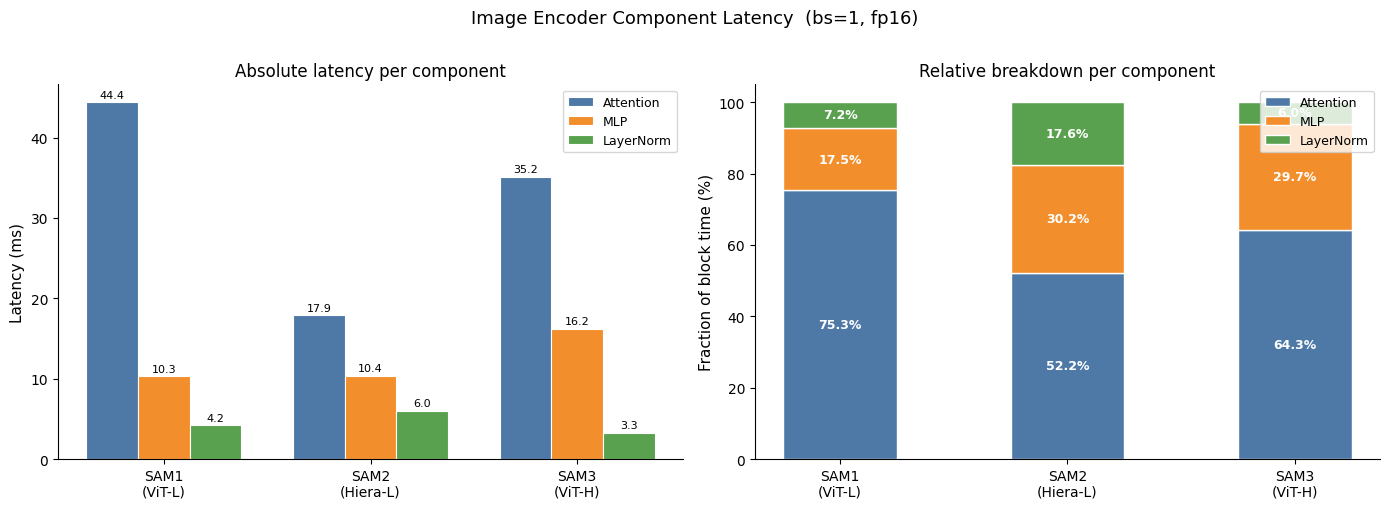

Saved → component_latency_comparison.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

PALETTE = {'attn': '#4e79a7', 'mlp': '#f28e2b', 'ln': '#59a14f'}

model_labels = ['SAM1\n(ViT-L)', f'SAM2\n(Hiera-L)', 'SAM3\n(ViT-H)']
attn_vals = [sam1_attn, sam2_attn, sam3_attn]
mlp_vals  = [sam1_mlp,  sam2_mlp,  sam3_mlp ]
ln_vals   = [sam1_ln,   sam2_ln,   sam3_ln  ]
totals    = [a + m + l for a, m, l in zip(attn_vals, mlp_vals, ln_vals)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Grouped bar: absolute ms ──────────────────────────────────────────────────
x, w = np.arange(3), 0.25
for offset, vals, label, color in [
    (-w, attn_vals, 'Attention', PALETTE['attn']),
    ( 0, mlp_vals,  'MLP',       PALETTE['mlp']),
    ( w, ln_vals,   'LayerNorm', PALETTE['ln']),
]:
    bars = ax1.bar(x + offset, vals, w, label=label, color=color, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=8)

ax1.set_xticks(x)
ax1.set_xticklabels(model_labels, fontsize=10)
ax1.set_ylabel('Latency (ms)', fontsize=11)
ax1.set_title('Absolute latency per component', fontsize=12)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# ── Stacked bar: relative % ───────────────────────────────────────────────────
attn_pct = [a / t * 100 for a, t in zip(attn_vals, totals)]
mlp_pct  = [m / t * 100 for m, t in zip(mlp_vals,  totals)]
ln_pct   = [l / t * 100 for l, t in zip(ln_vals,   totals)]

ax2.bar(x, attn_pct, 0.5, label='Attention', color=PALETTE['attn'], edgecolor='white')
ax2.bar(x, mlp_pct,  0.5, label='MLP',       color=PALETTE['mlp'],  edgecolor='white', bottom=attn_pct)
ax2.bar(x, ln_pct,   0.5, label='LayerNorm', color=PALETTE['ln'],   edgecolor='white',
        bottom=[a + m for a, m in zip(attn_pct, mlp_pct)])

for i, (a, m, l) in enumerate(zip(attn_pct, mlp_pct, ln_pct)):
    for pct, offset, col in [(a, a/2, 'white'), (m, a+m/2, 'white'), (l, a+m+l/2, 'white')]:
        if pct > 4:
            ax2.text(i, offset, f'{pct:.1f}%', ha='center', va='center',
                     fontsize=9, color=col, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(model_labels, fontsize=10)
ax2.set_ylim(0, 105)
ax2.set_ylabel('Fraction of block time (%)', fontsize=11)
ax2.set_title('Relative breakdown per component', fontsize=12)
ax2.legend(fontsize=9, loc='upper right')
ax2.spines[['top', 'right']].set_visible(False)

fig.suptitle(f'Image Encoder Component Latency  (bs={BATCH}, fp16)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('component_latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → component_latency_comparison.png')

## 6 — Per-block breakdown: SAM1

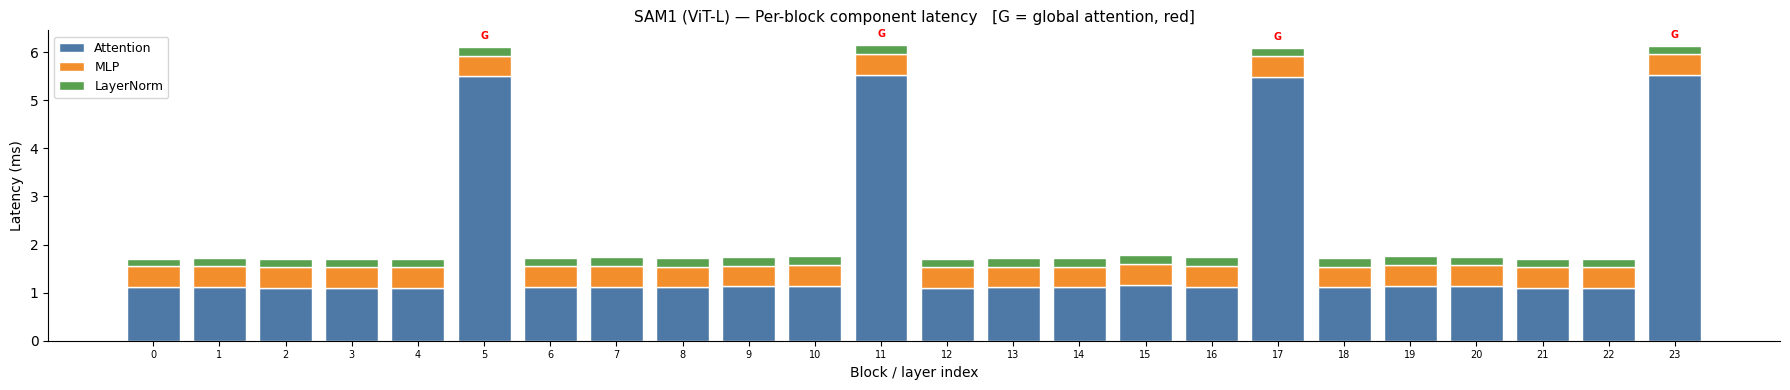

In [9]:
def plot_per_block(per_block, title, save_path=None, figsize=(18, 4)):
    fig, ax = plt.subplots(figsize=figsize)
    idxs = [b['idx']  for b in per_block]
    a_ms = [b['attn'] for b in per_block]
    m_ms = [b['mlp']  for b in per_block]
    l_ms = [b['ln']   for b in per_block]
    x = np.arange(len(idxs))

    ax.bar(x, a_ms, label='Attention', color=PALETTE['attn'], edgecolor='white')
    ax.bar(x, m_ms, label='MLP',       color=PALETTE['mlp'],  edgecolor='white', bottom=a_ms)
    ax.bar(x, l_ms, label='LayerNorm', color=PALETTE['ln'],   edgecolor='white',
           bottom=[a + m for a, m in zip(a_ms, m_ms)])

    for b in per_block:
        if b['is_global']:
            total = b['attn'] + b['mlp'] + b['ln']
            ax.text(b['idx'], total + total * 0.02, 'G', ha='center', va='bottom',
                    fontsize=7, color='red', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in idxs], fontsize=7)
    ax.set_xlabel('Block / layer index', fontsize=10)
    ax.set_ylabel('Latency (ms)', fontsize=10)
    ax.set_title(title + '   [G = global attention, red]', fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_per_block(sam1_per_block, 'SAM1 (ViT-L) — Per-block component latency', 'sam1_per_block.png')

## 7 — Per-block breakdown: SAM2

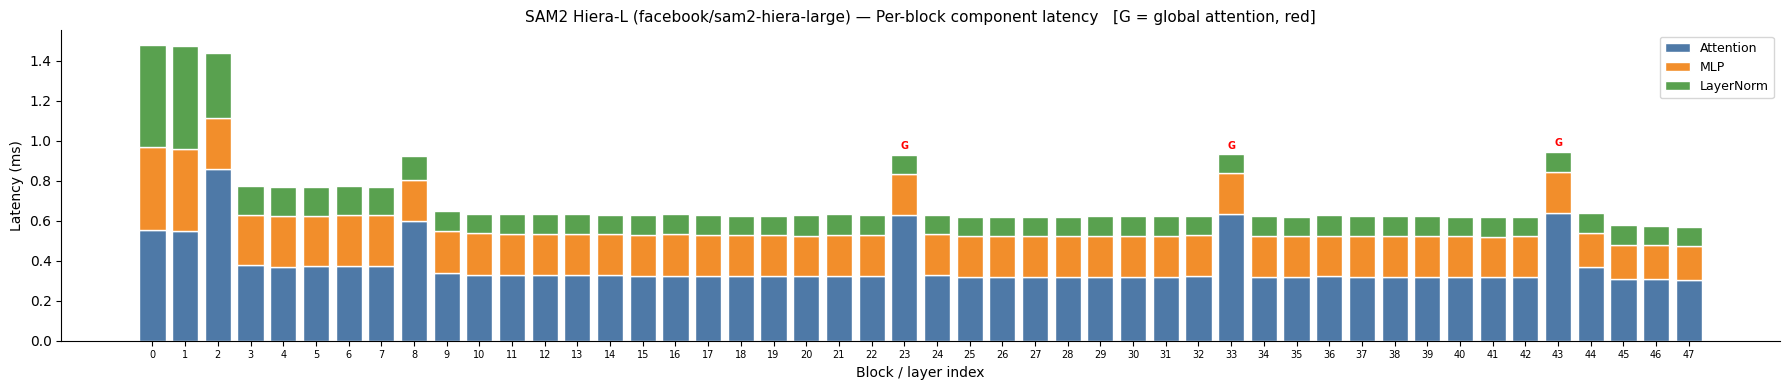

In [10]:
plot_per_block(sam2_per_block, f'SAM2 Hiera-L ({SAM2_HF_ID}) — Per-block component latency', 'sam2_per_block.png')

## 8 — Per-layer breakdown: SAM3

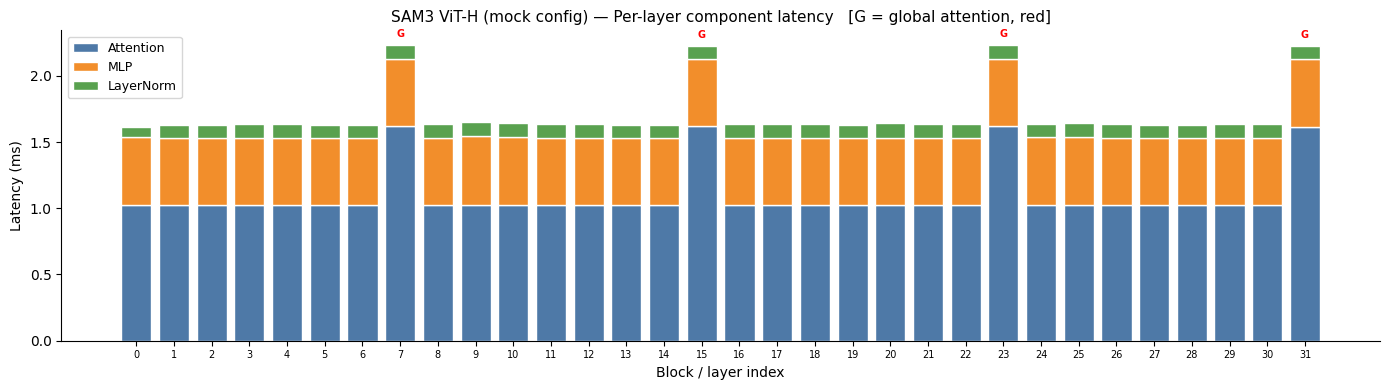

In [11]:
tag3 = SAM3_HF_ID if not SAM3_MOCK else 'mock config'
plot_per_block(sam3_per_layer, f'SAM3 ViT-H ({tag3}) — Per-layer component latency',
               'sam3_per_layer.png', figsize=(14, 4))

## 9 — Window vs Global attention (per model)

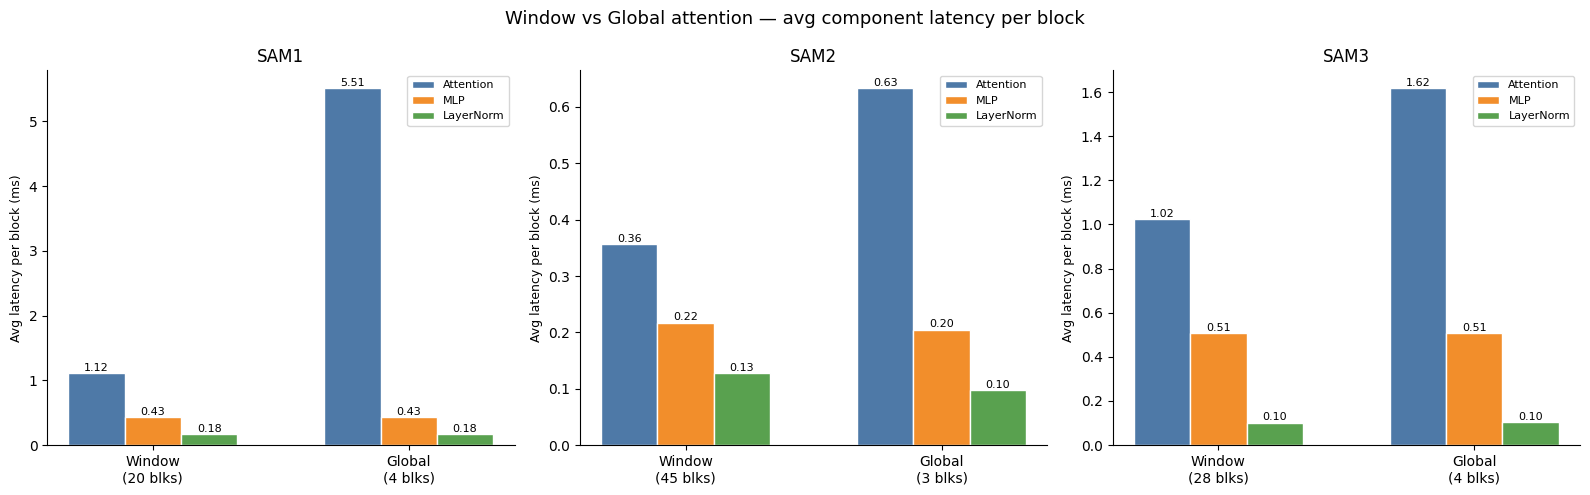

In [12]:
def win_vs_global_stats(per_block):
    win  = [b for b in per_block if not b['is_global']]
    glob = [b for b in per_block if     b['is_global']]
    def avg(lst, k): return np.mean([b[k] for b in lst]) if lst else 0.0
    return {
        'win' : {'n': len(win),  'attn': avg(win,  'attn'), 'mlp': avg(win,  'mlp'), 'ln': avg(win,  'ln')},
        'glob': {'n': len(glob), 'attn': avg(glob, 'attn'), 'mlp': avg(glob, 'mlp'), 'ln': avg(glob, 'ln')},
    }

stats = {
    'SAM1': win_vs_global_stats(sam1_per_block),
    'SAM2': win_vs_global_stats(sam2_per_block),
    'SAM3': win_vs_global_stats(sam3_per_layer),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
comps  = ['attn', 'mlp', 'ln']
clabels = ['Attention', 'MLP', 'LayerNorm']
colors = list(PALETTE.values())

for ax, (model_name, s) in zip(axes, stats.items()):
    groups = []
    xlabels = []
    if s['win']['n']:
        groups.append([s['win'][c]  for c in comps])
        xlabels.append(f"Window\n({s['win']['n']} blks)")
    if s['glob']['n']:
        groups.append([s['glob'][c] for c in comps])
        xlabels.append(f"Global\n({s['glob']['n']} blks)")

    x = np.arange(len(groups))
    w = 0.22
    for ci, (comp_label, color) in enumerate(zip(clabels, colors)):
        vals = [g[ci] for g in groups]
        bars = ax.bar(x + (ci - 1) * w, vals, w, label=comp_label, color=color, edgecolor='white')
        for bar, v in zip(bars, vals):
            if v > 0.005:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=10)
    ax.set_ylabel('Avg latency per block (ms)', fontsize=9)
    ax.set_title(model_name, fontsize=12)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Window vs Global attention — avg component latency per block', fontsize=13)
plt.tight_layout()
plt.savefig('win_vs_global_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10 — Attention sub-op breakdown: SAM1 & SAM3

Time each arithmetic step inside `Attention.forward`:

| Model | Sub-ops |
|-------|---------|
| SAM1  | `qkv` → `rel_pos` → `softmax` → `pv` → `proj` |
| SAM3  | `q_proj` · `k_proj` · `v_proj` → `rope` → `attn_compute` → `pv` → `o_proj` |

In [13]:
# ── Shared: context-manager wrapper around CUDATimer ─────────────────────────
from contextlib import contextmanager

@contextmanager
def record(timer: CUDATimer):
    timer.start()
    try:
        yield
    finally:
        timer.stop()

print('record() context manager ready.')

record() context manager ready.


### SAM1 attention sub-ops

In [14]:
import torch.nn.functional as F
from segment_anything.modeling.image_encoder import Attention as SAM1Attention
from segment_anything.modeling.image_encoder import add_decomposed_rel_pos

SAM1_SUBOPS = ('qkv', 'qk_matmul', 'rel_pos', 'softmax', 'pv', 'proj')

def make_sam1_attn_forward(attn: SAM1Attention, timers: dict, shapes: list):
    def forward(x: torch.Tensor) -> torch.Tensor:
        B, H, W, _ = x.shape
        shapes.append((B, H, W, x.shape[-1]))   # record input shape on first call

        with record(timers['qkv']):
            qkv = attn.qkv(x).reshape(B, H * W, 3, attn.num_heads, -1).permute(2, 0, 3, 1, 4)
            q, k, v = qkv.reshape(3, B * attn.num_heads, H * W, -1).unbind(0)

        with record(timers['qk_matmul']):
            a = (q * attn.scale) @ k.transpose(-2, -1)

        with record(timers['rel_pos']):
            if attn.use_rel_pos:
                a = add_decomposed_rel_pos(a, q, attn.rel_pos_h, attn.rel_pos_w, (H, W), (H, W))

        with record(timers['softmax']):
            a = a.softmax(dim=-1)

        with record(timers['pv']):
            out = (a @ v).view(B, attn.num_heads, H, W, -1).permute(0, 2, 3, 1, 4).reshape(B, H, W, -1)

        with record(timers['proj']):
            out = attn.proj(out)

        return out
    return forward


# ── Attach patched forwards ───────────────────────────────────────────────────
sam1_subop_timers = {}
sam1_attn_shapes  = {}   # block_idx -> (B, H, W, C) of the windowed/full input
sam1_orig_fwds    = []

for i, blk in enumerate(enc1.blocks):
    block_timers = {op: CUDATimer() for op in SAM1_SUBOPS}
    shape_buf    = []
    sam1_subop_timers[i] = block_timers
    sam1_attn_shapes[i]  = shape_buf
    sam1_orig_fwds.append((blk.attn, blk.attn.forward))
    blk.attn.forward = make_sam1_attn_forward(blk.attn, block_timers, shape_buf)

# ── Profile ───────────────────────────────────────────────────────────────────
profile_encoder(
    encoder_fn=lambda x: enc1(x),
    dummy_fn=lambda: torch.randn(BATCH, 3, IMG1, IMG1, device=DEVICE, dtype=torch.float16),
    n_warmup=N_WARMUP, n_runs=N_RUNS,
    timers={k: v for d in sam1_subop_timers.values() for k, v in d.items()},
)

# ── Restore original forwards ─────────────────────────────────────────────────
for attn_mod, orig_fwd in sam1_orig_fwds:
    attn_mod.forward = orig_fwd

# ── Aggregate & report ────────────────────────────────────────────────────────
sam1_subop_mean = {
    op: sum(sam1_subop_timers[i][op].mean() for i in range(n1))
    for op in SAM1_SUBOPS
}

print(f'SAM1 attention sub-ops — total across all {n1} blocks:')
for op, ms in sam1_subop_mean.items():
    print(f'  {op:<12} {ms:.3f} ms  ({ms / sum(sam1_subop_mean.values()) * 100:.1f}%)')

print(f'\nSAM1 attention input shapes (block → (B, H, W, C)):')
print(f'  {"blk":>4}  {"type":<8}  {"input shape":<22}  seq_len')
print(f'  {"-"*50}')
for i in range(n1):
    ws   = getattr(enc1.blocks[i], 'window_size', 0)
    kind = 'global' if ws == 0 else f'win{ws}'
    shp  = sam1_attn_shapes[i][0] if sam1_attn_shapes[i] else '?'
    seq  = shp[1] * shp[2] if isinstance(shp, tuple) else '?'
    print(f'  {i:>4}  {kind:<8}  {str(shp):<22}  {seq}')


SAM1 attention sub-ops — total across all 24 blocks:
  qkv          5.053 ms  (10.2%)
  qk_matmul    6.602 ms  (13.3%)
  rel_pos      24.450 ms  (49.3%)
  softmax      6.756 ms  (13.6%)
  pv           4.446 ms  (9.0%)
  proj         2.325 ms  (4.7%)

SAM1 attention input shapes (block → (B, H, W, C)):
   blk  type      input shape             seq_len
  --------------------------------------------------
     0  win14     (25, 14, 14, 1024)      196
     1  win14     (25, 14, 14, 1024)      196
     2  win14     (25, 14, 14, 1024)      196
     3  win14     (25, 14, 14, 1024)      196
     4  win14     (25, 14, 14, 1024)      196
     5  global    (1, 64, 64, 1024)       4096
     6  win14     (25, 14, 14, 1024)      196
     7  win14     (25, 14, 14, 1024)      196
     8  win14     (25, 14, 14, 1024)      196
     9  win14     (25, 14, 14, 1024)      196
    10  win14     (25, 14, 14, 1024)      196
    11  global    (1, 64, 64, 1024)       4096
    12  win14     (25, 14, 14, 1024)    

### SAM3 attention sub-ops

In [15]:
from transformers.models.sam3.modeling_sam3 import apply_rotary_pos_emb_2d

SAM3_SUBOPS = ('q_proj', 'k_proj', 'v_proj', 'rope', 'attn_compute', 'pv', 'o_proj')

def make_sam3_attn_forward(attn, timers: dict, shapes: list):
    def forward(hidden_states: torch.Tensor, position_embeddings, **kwargs):
        B, H, W, _ = hidden_states.shape
        shapes.append((B, H, W, hidden_states.shape[-1]))

        nh, hd    = attn.num_attention_heads, attn.head_dim
        new_shape = (B, H * W, nh, hd)

        with record(timers['q_proj']):
            q = attn.q_proj(hidden_states).view(*new_shape).transpose(1, 2)
        with record(timers['k_proj']):
            k = attn.k_proj(hidden_states).view(*new_shape).transpose(1, 2)
        with record(timers['v_proj']):
            v = attn.v_proj(hidden_states).view(*new_shape).transpose(1, 2)

        cos, sin = position_embeddings
        with record(timers['rope']):
            q, k = apply_rotary_pos_emb_2d(q, k, cos=cos, sin=sin)

        with record(timers['attn_compute']):
            w = torch.matmul(q, k.transpose(2, 3)) * attn.scaling
            w = F.softmax(w, dim=-1)

        with record(timers['pv']):
            out = torch.matmul(w, v)
            out = out.transpose(1, 2).contiguous().reshape(B, H, W, -1)

        with record(timers['o_proj']):
            out = attn.o_proj(out)

        return out, w
    return forward


# ── Attach patched forwards ───────────────────────────────────────────────────
sam3_subop_timers = {}
sam3_attn_shapes  = {}
sam3_orig_fwds    = []

for i, layer in enumerate(backbone3.layers):
    block_timers = {op: CUDATimer() for op in SAM3_SUBOPS}
    shape_buf    = []
    sam3_subop_timers[i] = block_timers
    sam3_attn_shapes[i]  = shape_buf
    sam3_orig_fwds.append((layer.attention, layer.attention.forward))
    layer.attention.forward = make_sam3_attn_forward(layer.attention, block_timers, shape_buf)

# ── Profile ───────────────────────────────────────────────────────────────────
profile_encoder(
    encoder_fn=lambda x: enc3(pixel_values=x),
    dummy_fn=lambda: torch.randn(BATCH, 3, IMG3, IMG3, device=DEVICE, dtype=torch.float16),
    n_warmup=N_WARMUP, n_runs=N_RUNS,
    timers={k: v for d in sam3_subop_timers.values() for k, v in d.items()},
)

# ── Restore original forwards ─────────────────────────────────────────────────
for attn_mod, orig_fwd in sam3_orig_fwds:
    attn_mod.forward = orig_fwd

# ── Aggregate & report ────────────────────────────────────────────────────────
sam3_subop_mean = {
    op: sum(sam3_subop_timers[i][op].mean() for i in range(n3))
    for op in SAM3_SUBOPS
}

print(f'SAM3 attention sub-ops — total across all {n3} layers:')
for op, ms in sam3_subop_mean.items():
    print(f'  {op:<14} {ms:.3f} ms  ({ms / sum(sam3_subop_mean.values()) * 100:.1f}%)')

print(f'\nSAM3 attention input shapes (layer → (B, H, W, C)):')
print(f'  {"lyr":>4}  {"type":<8}  {"input shape":<22}  seq_len')
print(f'  {"-"*50}')
for i in range(n3):
    kind = 'global' if i in global_idxs3 else f'win{backbone3.config.window_size}'
    shp  = sam3_attn_shapes[i][0] if sam3_attn_shapes[i] else '?'
    seq  = shp[1] * shp[2] if isinstance(shp, tuple) else '?'
    print(f'  {i:>4}  {kind:<8}  {str(shp):<22}  {seq}')


SAM3 attention sub-ops — total across all 32 layers:
  q_proj         2.156 ms  (2.9%)
  k_proj         3.274 ms  (4.5%)
  v_proj         3.180 ms  (4.3%)
  rope           20.516 ms  (28.0%)
  attn_compute   32.284 ms  (44.0%)
  pv             8.535 ms  (11.6%)
  o_proj         3.398 ms  (4.6%)

SAM3 attention input shapes (layer → (B, H, W, C)):
   lyr  type      input shape             seq_len
  --------------------------------------------------
     0  win24     (9, 24, 24, 1024)       576
     1  win24     (9, 24, 24, 1024)       576
     2  win24     (9, 24, 24, 1024)       576
     3  win24     (9, 24, 24, 1024)       576
     4  win24     (9, 24, 24, 1024)       576
     5  win24     (9, 24, 24, 1024)       576
     6  win24     (9, 24, 24, 1024)       576
     7  global    (1, 72, 72, 1024)       5184
     8  win24     (9, 24, 24, 1024)       576
     9  win24     (9, 24, 24, 1024)       576
    10  win24     (9, 24, 24, 1024)       576
    11  win24     (9, 24, 24, 1024)      

### Plots

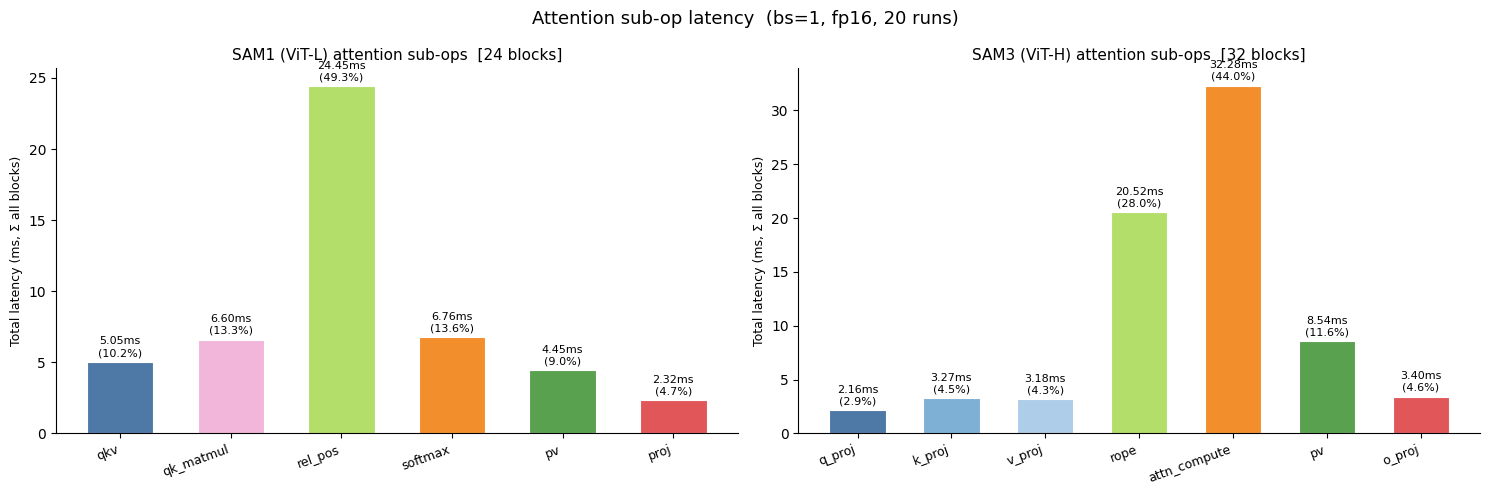

Saved → attn_subop_comparison.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ── color map: one colour per logical sub-op category ────────────────────────
SUBOP_COLORS = {
    # QKV projections
    'qkv':          '#4e79a7',
    'q_proj':       '#4e79a7',
    'k_proj':       '#7eb0d5',
    'v_proj':       '#aecde8',
    # positional encoding
    'qk_matmul':    '#f1b6da',
    'rel_pos':      '#b3de69',
    'rope':         '#b3de69',
    # attention compute
    'softmax':      '#f28e2b',
    'attn_compute': '#f28e2b',
    # weighted sum
    'pv':           '#59a14f',
    # output projection
    'proj':         '#e15759',
    'o_proj':       '#e15759',
}

def _subop_bar(ax, subop_mean, title, n_blocks):
    ops  = list(subop_mean.keys())
    vals = list(subop_mean.values())
    total = sum(vals)
    colors = [SUBOP_COLORS.get(op, '#aaaaaa') for op in ops]
    x = np.arange(len(ops))

    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.8, width=0.6)
    for bar, v in zip(bars, vals):
        pct = v / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total * 0.005,
                f'{v:.2f}ms\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(ops, fontsize=9, rotation=20, ha='right')
    ax.set_ylabel('Total latency (ms, Σ all blocks)', fontsize=9)
    ax.set_title(f'{title}  [{n_blocks} blocks]', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
_subop_bar(ax1, sam1_subop_mean, 'SAM1 (ViT-L) attention sub-ops', n1)
_subop_bar(ax2, sam3_subop_mean, 'SAM3 (ViT-H) attention sub-ops', n3)

fig.suptitle(f'Attention sub-op latency  (bs={BATCH}, fp16, {N_RUNS} runs)', fontsize=13)
plt.tight_layout()
plt.savefig('attn_subop_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → attn_subop_comparison.png')

### Per-block heatmap (latency per sub-op per block)

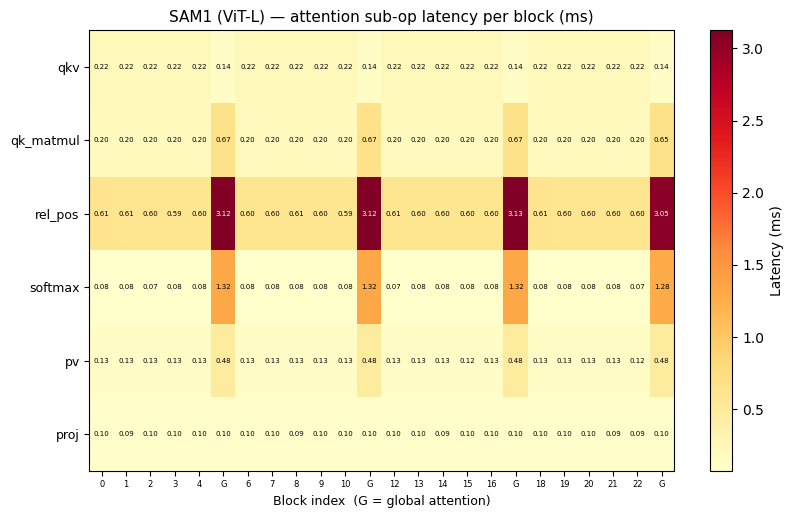

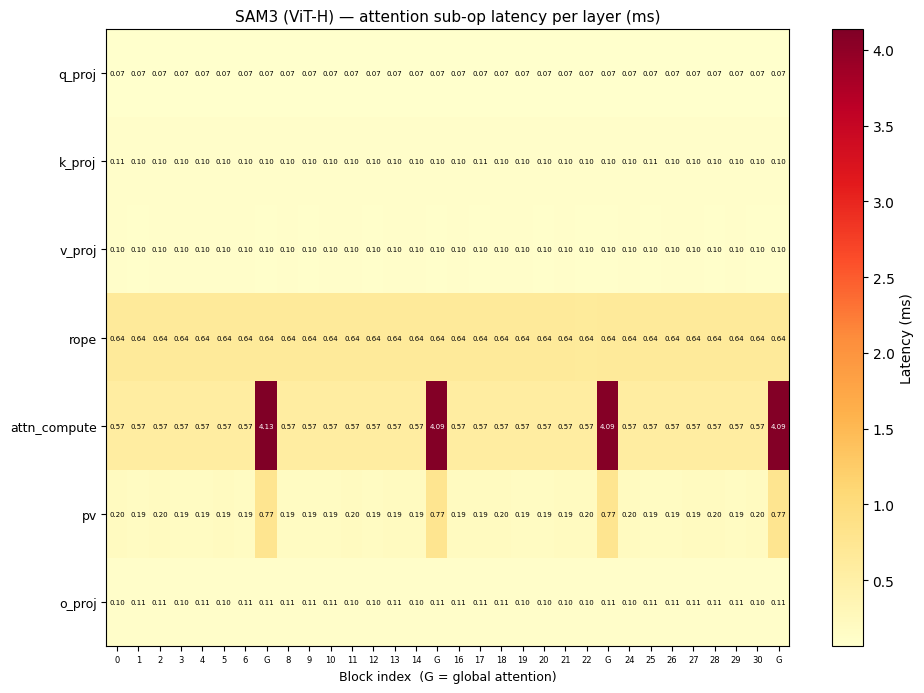

In [17]:
def plot_subop_heatmap(subop_timers, subops, n_blocks, title, global_set=None, save_path=None):
    data = np.array([[subop_timers[i][op].mean() for op in subops] for i in range(n_blocks)])

    fig, ax = plt.subplots(figsize=(max(8, len(subops) * 1.4), max(5, n_blocks * 0.22)))
    im = ax.imshow(data.T, aspect='auto', cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label='Latency (ms)')

    ax.set_xticks(range(n_blocks))
    xlabels = []
    for i in range(n_blocks):
        tag = 'G' if (global_set and i in global_set) else str(i)
        xlabels.append(tag)
    ax.set_xticklabels(xlabels, fontsize=6)
    ax.set_yticks(range(len(subops)))
    ax.set_yticklabels(subops, fontsize=9)

    for j in range(len(subops)):
        for i in range(n_blocks):
            v = data[i, j]
            ax.text(i, j, f'{v:.2f}', ha='center', va='center',
                    fontsize=5, color='black' if v < data.max() * 0.6 else 'white')

    ax.set_xlabel('Block index  (G = global attention)', fontsize=9)
    ax.set_title(title, fontsize=11)
    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_subop_heatmap(
    sam1_subop_timers, SAM1_SUBOPS, n1,
    f'SAM1 (ViT-L) — attention sub-op latency per block (ms)',
    global_set={i for i, b in enumerate(enc1.blocks) if getattr(b, 'window_size', 1) == 0},
    save_path='sam1_attn_subop_heatmap.png'
)

plot_subop_heatmap(
    sam3_subop_timers, SAM3_SUBOPS, n3,
    f'SAM3 (ViT-H) — attention sub-op latency per layer (ms)',
    global_set=global_idxs3,
    save_path='sam3_attn_subop_heatmap.png'
)

In [18]:
import torch
from algo.gradtome.z_utils import encode, decode, get_z_order, get_z_inverse
def test_z_curve():
    H, W = 4, 4
    num_bits = 2
    num_dims = 2
    
    # Test encode/decode consistency
    rows = torch.arange(H)
    cols = torch.arange(W)
    grid_r, grid_c = torch.meshgrid(rows, cols, indexing="ij")
    coords = torch.stack([grid_r.flatten(), grid_c.flatten()], dim=1)
    
    z_indices = encode(coords, num_dims, num_bits)
    decoded_coords = decode(z_indices, num_dims, num_bits)
    
    assert torch.all(coords == decoded_coords), "Encode/Decode consistency failed"
    print("Encode/Decode consistency passed")
    
    # Test permutations
    perm = get_z_order(H, W)
    inv_perm = get_z_inverse(H, W)
    
    # tokens in raster order: 0, 1, 2, ..., 15
    tokens = torch.arange(H * W)
    tokens_z = tokens[perm]
    tokens_restored = tokens_z[inv_perm]
    
    assert torch.all(tokens == tokens_restored), "Permutation/Inverse consistency failed"
    print("Permutation/Inverse consistency passed")
    
    print("Raster order:")
    print(tokens.view(H, W))
    
    print("\nZ-order indices for each raster position (row, col):")
    print(z_indices.view(H, W))
    
    print("\nTokens in Z-order:")
    print(tokens_z)
    
    # For a 2x2 grid:
    # (0,0) -> 0
    # (0,1) -> 1
    # (1,0) -> 2
    # (1,1) -> 3
    # This is the standard Z-order (Morton) for (row, col)
    # Let's check 2x2 subset
    expected_z_2x2 = torch.tensor([0, 1, 2, 3])
    actual_z_2x2 = encode(torch.tensor([[0,0], [0,1], [1,0], [1,1]]), 2, 1)
    assert torch.all(expected_z_2x2 == actual_z_2x2), f"Expected {expected_z_2x2}, got {actual_z_2x2}"
    print("2x2 Morton test passed")

test_z_curve()

ModuleNotFoundError: No module named 'algo'

In [1]:
import math
m_block = 32
n_block = 32
Sq = 4096 

num_m_blocks = math.ceil(Sq / m_block)
num_n_blocks = math.ceil(Sq / n_block)

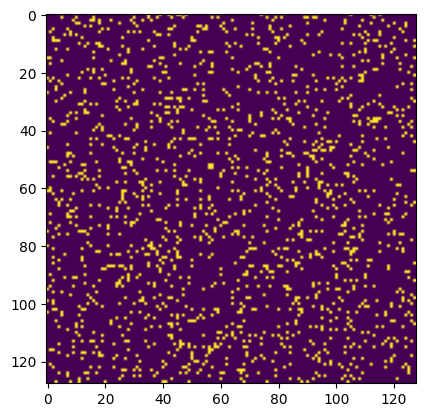

In [6]:
from cutlass.cute.runtime import from_dlpack 
import torch
from matplotlib import pyplot as plt
def make_block_mask(B, H, nm, nn, sparsity):
    """(B, H, nm, nn) int32 block mask; 1=compute, 0=skip."""
    t = torch.ones(B, H, nm, nn, dtype=torch.int32, device="cuda")
    if sparsity > 0.0:
        n_zero = int(sparsity * nm * nn)
        idx = torch.randperm(nm * nn, device="cuda")[:n_zero]
        t.view(B, H, -1)[:, :, idx] = 0
    ct = from_dlpack(t, assumed_align=4)
    return ct, t

mask = make_block_mask(1, 16, num_m_blocks, num_n_blocks, 0.9)
plt.imshow(mask[1][0][0].cpu().numpy())
